## 기본 통계량 및 분포 분석

## 뉴욕 지역별 숙소 특성 및 가격 분포 분석
### 목적 : 뉴욕 어떤 숙소 유형으로 시작하는게 유리할까?
- 지역별 숙소 개수 → 현황같은데.. +시각화 → 여기서 더 추가할 수 있나?
- 지역별 평균 가격 → 지역별로 평균 가격에 차이가 있을 것이다.
- 숙소 유형별 가격 비교 → 숙소 유형에 따라 가격에 차이가 있을 것이다.
- 리뷰나 평점 → 상관계수 .........

---
## 데이터로드

In [225]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [226]:
#데이터 불러오깅
df = pd.read_csv("data/first_clean_data.csv", index_col=0)


In [227]:
df.shape

(22248, 38)

In [293]:
# ============================================================
# 전체 컬럼 설명
# ============================================================
# • id                                      : 숙소 고유 ID
# • name                                    : 숙소 이름
# • description                             : 숙소 설명
# • host_id                                 : 호스트 고유 ID
# • host_since                              : 호스트 가입일
# • host_response_time                      : 호스트 응답 시간
# • host_response_rate                      : 호스트 응답률
# • host_acceptance_rate                    : 호스트 예약 요청 수락률
# • host_is_superhost                       : 슈퍼호스트 여부
# • neighbourhood_cleansed                  : 숙소가 위치한 세부 지역
# • neighbourhood_group_cleansed            : 숙소가 위치한 상위 지역(행정구역)
# • latitude                                : 위도
# • longitude                               : 경도
# • property_type                           : 숙소 유형
# • room_type                               : 방 유형
# • accommodates                            : 수용 가능 인원
# • bedrooms                                : 침실 수
# • beds                                    : 침대 수
# • amenities                               : 편의시설
# • price                                   : 가격
# • availability_365                        : 365일 예약 가능일 수
# • number_of_reviews                       : 전체 리뷰 수
# • number_of_reviews_ltm                   : 최근 12개월 리뷰 수
# • estimated_occupancy_l365d               : 최근 365일 추정 점유일 수
# • estimated_revenue_l365d                 : 최근 365일 추정 매출
# • review_scores_rating                    : 전체 평점
# • review_scores_accuracy                  : 정확성 평점
# • review_scores_cleanliness               : 청결도 평점
# • review_scores_checkin                   : 체크인 평점
# • review_scores_communication             : 소통 평점
# • review_scores_location                  : 위치 평점
# • review_scores_value                     : 가성비 평점
# • calculated_host_listings_count          : 호스트 전체 등록 숙소 수
# • calculated_host_listings_count_entire_homes   : 호스트의 집 전체 숙소 수
# • calculated_host_listings_count_private_rooms  : 호스트의 개인실 숙소 수
# • calculated_host_listings_count_shared_rooms   : 호스트의 다인실 숙소 수
# • reviews_per_month                       : 월평균 리뷰 수
# • log_price                               : 가격 로그 변환값

In [228]:
df.info()

<class 'pandas.DataFrame'>
Index: 22248 entries, 0 to 37433
Data columns (total 38 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            22248 non-null  int64  
 1   name                                          22248 non-null  str    
 2   description                                   22248 non-null  str    
 3   host_id                                       22248 non-null  int64  
 4   host_since                                    22248 non-null  str    
 5   host_response_time                            22248 non-null  float64
 6   host_response_rate                            22248 non-null  float64
 7   host_acceptance_rate                          22248 non-null  float64
 8   host_is_superhost                             22248 non-null  str    
 9   neighbourhood_cleansed                        22248 non-null  str    
 10  ne

In [229]:
df.head()

,id,name,description,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,amenities,price,availability_365,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,log_price
0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,62165,2009-12-11,-1.0,-1.0,87.0,False,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",200,362,9,0,0,0.0,4.88,5.00,4.80,5.00,5.00,5.00,5.00,1,0,1,0,0.05,5.303305
1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,157798,2010-07-04,-1.0,-1.0,100.0,False,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",82,204,102,0,0,0.0,4.77,4.82,4.76,4.88,4.90,4.38,4.71,1,0,1,0,0.58,4.418841
2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...",165789,2010-07-13,3.0,100.0,40.0,False,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",765,326,43,0,0,0.0,4.70,4.83,4.52,4.88,4.88,4.86,4.62,1,0,1,0,0.28,6.641182
3,38833,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,166532,2010-07-14,4.0,100.0,97.0,True,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",139,25,241,42,255,35445.0,4.85,4.87,4.50,4.96,4.96,4.79,4.82,1,1,0,0,1.36,4.941642
4,39282,“Work-from-home” from OUR home.,*Monthly Discount will automatically apply <br...,168525,2010-07-16,4.0,100.0,100.0,True,Williamsburg,Brooklyn,40.710651,-73.950874,Private room in rental unit,Private room,2,1.0,1.0,"[""Oven"", ""Rice maker"", ""Laundromat nearby"", ""L...",130,38,274,12,154,20020.0,4.82,4.83,4.61,4.94,4.88,4.85,4.78,2,0,2,0,1.54,4.875197


In [230]:
df.columns

Index(['id', 'name', 'description', 'host_id', 'host_since',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bedrooms', 'beds',
       'amenities', 'price', 'availability_365', 'number_of_reviews',
       'number_of_reviews_ltm', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value',
       'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'calculated_host_listings_count_private_rooms',
       'calculated_host_listings_count_shared_rooms', 'reviews_per_month',
       'log_price'],
      dtype='str')

In [231]:
df[['price','log_price']]

,price,log_price
0,200,5.303305
1,82,4.418841
2,765,6.641182
3,139,4.941642
4,130,4.875197
...,...,...
37429,72,4.290459
37430,58,4.077537
37431,299,5.703782
37432,200,5.303305


---
## 숙소 유형별 가격 비교

In [232]:
df.groupby("room_type")["price"].count().sort_values(ascending=False)

room_type
Entire home/apt    12635
Private room        9178
Hotel room           365
Shared room           70
Name: price, dtype: int64

In [233]:
df.groupby("room_type")["price"].mean().sort_values(ascending=False)

room_type
Hotel room         537.600000
Entire home/apt    265.557657
Shared room        169.728571
Private room       130.826869
Name: price, dtype: float64

<Axes: title={'center': 'price'}, xlabel='room_type'>

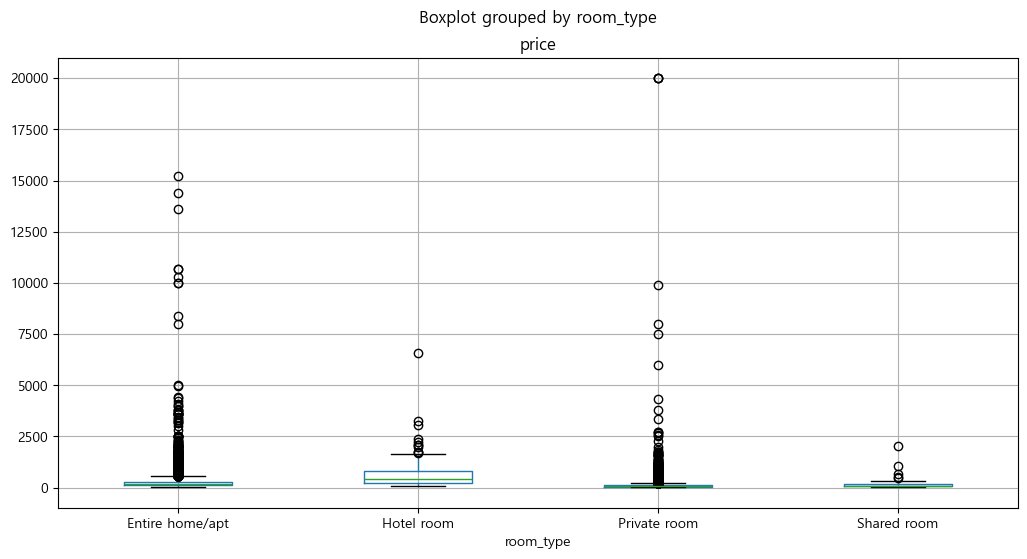

In [234]:
df.boxplot(column="price", by="room_type")

<Axes: title={'center': 'log_price'}, xlabel='room_type'>

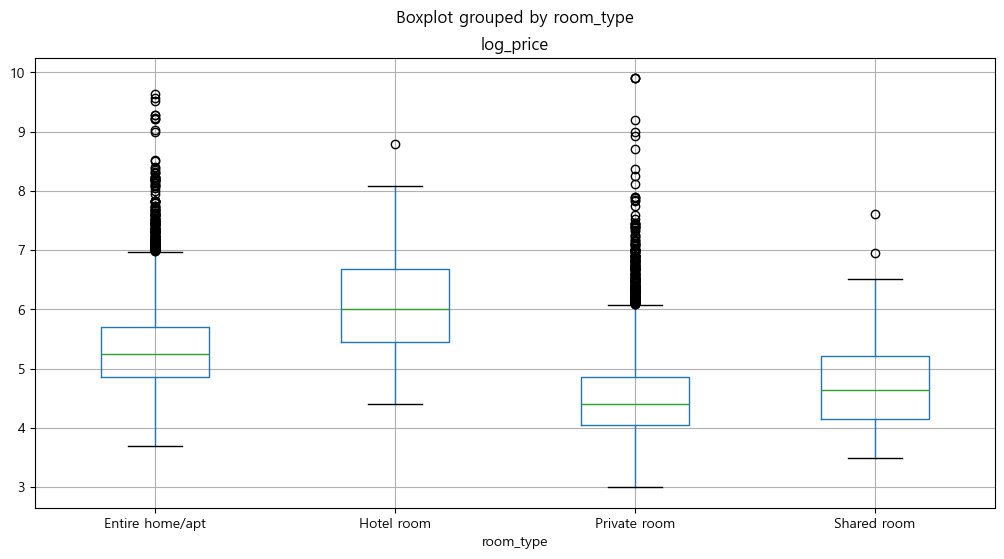

In [235]:
# 가격 log씌워서 boxplot
df.boxplot(column="log_price", by="room_type")

- Hotel의 중앙값(초록색) 가장 높아 가장 비싼 유형이다.
- Entire home/apt는 그다음으로 중앙값(초록색)이 높다.
- Private room과 Shared room의 중앙값(초록색)은 비슷했다.
- Shared room은 박스가 Private room에 비해 넓어 가격 변동이 조금 더 커 보인다.

## 숙소 유형별 차이가 유의미한가?

### 1. 가설설정
- 귀무가설 : 숙소 유형별로 평균 가격은 같다.
- 대립가설 : 숙소 유형별로 평균 가격이 다르다.

Entire home/apt, Hotel room, Private room, Shared room

In [236]:
df['room_type'].value_counts()

room_type
Entire home/apt    12635
Private room        9178
Hotel room           365
Shared room           70
Name: count, dtype: int64

In [237]:
g1 = df.loc[df['room_type']=='Entire home/apt','price']
g2 = df.loc[df['room_type']=='Private room','price']
g3 = df.loc[df['room_type']=='Hotel room','price']
g4 = df.loc[df['room_type']=='Shared room','price']

### 2. 검정방법 선택
- 후보1: 일원 ANOVA
    - 조건에 맞는지 1)정규성 2)등분산성 3)독립성 

#### 2-1) 정규성 확인하기

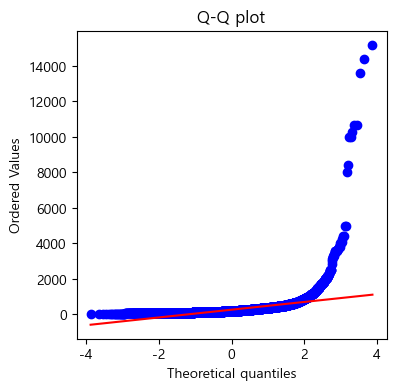

In [238]:
# q-q plot 

plt.figure(figsize=(4,4))
stats.probplot(g1, plot=plt)
plt.title("Q-Q plot")
plt.show()

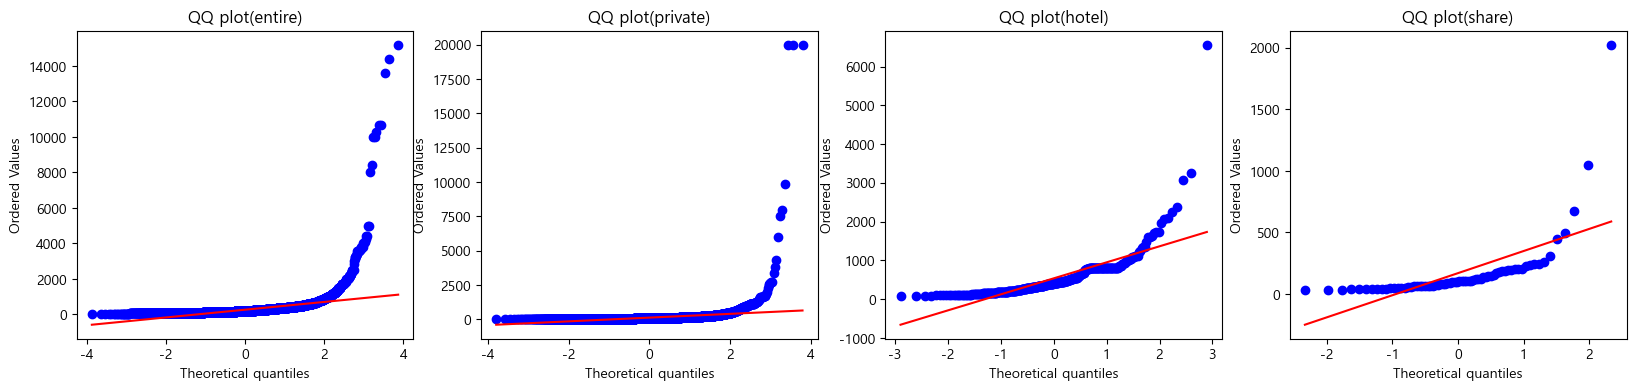

In [239]:
# q-q plot 시각화
fig, ax = plt.subplots(1,4, figsize=(20,4))
stats.probplot(g1, plot=ax[0])
ax[0].set_title("QQ plot(entire)")
stats.probplot(g2, plot=ax[1])
ax[1].set_title("QQ plot(private)")
stats.probplot(g3, plot=ax[2])
ax[2].set_title("QQ plot(hotel)")
stats.probplot(g4, plot=ax[3])
ax[3].set_title("QQ plot(share)")
plt.show()

- 정규성을 만족하지 않음
- 롱테일(오른쪽 꼬리가 긴 형태)

### 3. 유의수준 결정 : 0.05

### 4. 검정 통계량, p-value 계산

In [240]:
stat, p = stats.kruskal(g1, g2, g3, g4)
stat, p

(np.float64(7284.52185170291), np.float64(0.0))

### 5. 결과해석

p-value가 유의수준보다 낮으므로 귀무가설 기각.(p < 0.05)

- 귀무가설 : 숙소 유형별로 평균 가격은 같다.
- 대립가설 : 숙소 유형별로 평균 가격이 다르다.

## 사후검정 (Dunn test)

In [241]:
# Dunn 사후검정 
data = df[['room_type', 'price']].dropna()

posthoc = sp.posthoc_dunn(data, 
                        val_col="price",
                        group_col="room_type",
                        p_adjust="holm"
                        )

In [242]:
posthoc

,Entire home/apt,Hotel room,Private room,Shared room
Entire home/apt,1.000000e+00,4.350104e-37,0.000000e+00,2.217586e-13
Hotel room,4.350104e-37,1.000000e+00,8.469899e-252,6.290908e-33
Private room,0.000000e+00,8.469899e-252,1.000000e+00,4.542803e-02
Shared room,2.217586e-13,6.290908e-33,4.542803e-02,1.000000e+00


**해석 : Entire home/apt, Hotel room, Private room, Shared room 평균가격이 모두 서로 다르다 ( 유의 수준 0.05 기준)**

---
# 각 숙소 유형별로 상관관계가 있는 컬럼 찾기

In [243]:
df.columns

Index(['id', 'name', 'description', 'host_id', 'host_since',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bedrooms', 'beds',
       'amenities', 'price', 'availability_365', 'number_of_reviews',
       'number_of_reviews_ltm', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value',
       'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'calculated_host_listings_count_private_rooms',
       'calculated_host_listings_count_shared_rooms', 'reviews_per_month',
       'log_price'],
      dtype='str')

In [244]:
df['room_type'].value_counts()

room_type
Entire home/apt    12635
Private room        9178
Hotel room           365
Shared room           70
Name: count, dtype: int64


## 카이제곱 독립성 검정

룸 타입별 vs 지역

- 귀무가설 : 두 범주형 변수는 독립적이다.
- 대립가설 : 두 범주형 변수는 독립적이지 않다.

In [245]:
df

,id,name,description,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,amenities,price,availability_365,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,log_price
0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,62165,2009-12-11,-1.0,-1.0,87.0,False,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",200,362,9,0,0,0.0,4.88,5.00,4.80,5.00,5.00,5.00,5.00,1,0,1,0,0.05,5.303305
1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,157798,2010-07-04,-1.0,-1.0,100.0,False,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",82,204,102,0,0,0.0,4.77,4.82,4.76,4.88,4.90,4.38,4.71,1,0,1,0,0.58,4.418841
2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...",165789,2010-07-13,3.0,100.0,40.0,False,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",765,326,43,0,0,0.0,4.70,4.83,4.52,4.88,4.88,4.86,4.62,1,0,1,0,0.28,6.641182
3,38833,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,166532,2010-07-14,4.0,100.0,97.0,True,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",139,25,241,42,255,35445.0,4.85,4.87,4.50,4.96,4.96,4.79,4.82,1,1,0,0,1.36,4.941642
4,39282,“Work-from-home” from OUR home.,*Monthly Discount will automatically apply <br...,168525,2010-07-16,4.0,100.0,100.0,True,Williamsburg,Brooklyn,40.710651,-73.950874,Private room in rental unit,Private room,2,1.0,1.0,"[""Oven"", ""Rice maker"", ""Laundromat nearby"", ""L...",130,38,274,12,154,20020.0,4.82,4.83,4.61,4.94,4.88,4.85,4.78,2,0,2,0,1.54,4.875197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37429,1366333532374850165,Beautiful 1-Bed Apt in Harlem!,Welcome to your temporary home in the vibrant ...,40019013,2015-07-30,-1.0,-1.0,87.0,False,Harlem,Manhattan,40.813794,-73.952399,Private room in rental unit,Private room,1,1.0,1.0,"[""Air conditioning"", ""Carbon monoxide alarm"", ...",72,358,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN,4.290459
37430,1366717321390111215,Private Room w/ Ensuite Bath H,Stylish Private Rooms w/ En-Suite Baths in Bro...,483056418,2022-10-10,4.0,100.0,80.0,True,Bedford-Stuyvesant,Brooklyn,40.685500,-73.919510,Private room in rental unit,Private room,2,1.0,0.0,"[""Air conditioning"", ""Carbon monoxide alarm"", ...",58,363,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24,0,24,0,NaN,4.077537
37431,1366721904709517353,2 Bedroom on East Side,Located in the Murray Hill area and occupies a...,30283594,2015-03-30,4.0,94.0,99.0,False,Kips Bay,Manhattan,40.745290,-73.979380,Entire rental unit,Entire home/apt,5,2.0,3.0,"[""Air conditioning"", ""Carbon monoxide alarm"", ...",299,99,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48,48,0,0,NaN,5.703782
37432,1366722692755341871,Stylish 2Bd near Bryant Park,Enjoy everything the city has to offer while l...,407304997,2021-06-15,4.0,89.0,100.0,False,Theater District,Manhattan,40.757133,-73.983124,Entire rental unit,Entire home/apt,4,2.0,2.0,"[""Oven"", "

In [246]:
display(df['neighbourhood_group_cleansed'].isna().sum())
display(df['neighbourhood_group_cleansed'].value_counts(dropna=False))

np.int64(0)

neighbourhood_group_cleansed
Manhattan        10165
Brooklyn          7442
Queens            3414
Bronx              911
Staten Island      316
Name: count, dtype: int64

In [247]:
ct = pd.crosstab(df['room_type'], df['neighbourhood_group_cleansed'])
result = chi2_contingency(ct)

result

Chi2ContingencyResult(statistic=np.float64(1646.3567796675218), pvalue=np.float64(0.0), dof=12, expected_freq=array([[5.17371674e+02, 4.22643249e+03, 5.77286835e+03, 1.93886597e+03,
        1.79461525e+02],
       [1.49458378e+01, 1.22093222e+02, 1.66766676e+02, 5.60099784e+01,
        5.18428623e+00],
       [3.75816163e+02, 3.07005915e+03, 4.19338233e+03, 1.40838242e+03,
        1.30359942e+02],
       [2.86632506e+00, 2.34151384e+01, 3.19826501e+01, 1.07416397e+01,
        9.94246674e-01]]))

p-value가 0에 가까우니까 두 범주형 변수는 관계가 있다.

# 크래머 v계수 계산하기

In [248]:
def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table).statistic
    n = contingency_table.sum().sum()
    r = contingency_table.shape[0]
    c = contingency_table.shape[1]
    v = np.sqrt(chi2/(n*min(r-1,c-1)))
    return v

In [249]:
cramers_v(ct)

np.float64(0.15705648117352444)

크래머V 계수가 0.1이상으로 약한 상관관계가 있다.

In [250]:
categorical_cols = [
    "host_response_time",
    "host_is_superhost",
    "neighbourhood_cleansed",
    "neighbourhood_group_cleansed"
]

In [251]:
ct1 = pd.crosstab(df['room_type'], df['host_response_time'])
ct2 = pd.crosstab(df['room_type'], df['host_is_superhost'])
ct3 = pd.crosstab(df['room_type'], df['neighbourhood_cleansed'])
ct4 = pd.crosstab(df['room_type'], df['neighbourhood_group_cleansed'])

print(cramers_v(ct1))
print(cramers_v(ct2))
print(cramers_v(ct3))
print(cramers_v(ct4))

0.08277075416451467
0.06156069544850748
0.2863052441361376
0.15705648117352444


In [252]:
for col in categorical_cols:
    drop = df[['room_type', col]].dropna()
    ct = pd.crosstab(drop['room_type'], drop[col])
    print(f"컬럼명 : {col}, 크래머v: {cramers_v(ct)}")

컬럼명 : host_response_time, 크래머v: 0.08277075416451467
컬럼명 : host_is_superhost, 크래머v: 0.06156069544850748
컬럼명 : neighbourhood_cleansed, 크래머v: 0.2863052441361376
컬럼명 : neighbourhood_group_cleansed, 크래머v: 0.15705648117352444


해석
- host_response_time => 0.08 매우약한 상관관계
- host_is_superhost => 0.06 매우약한 상관관계
- neighbourhood_cleansed => 0.28 약한 상관관계
- neighbourhood_group_cleansed => 0.15 매우약한 상관관계

# 범주 vs 수치형 상관관계 확인

In [253]:
# 2. 그 중 수치형 데이터만 추출
numeric_col = df.select_dtypes(include=['number']).columns.tolist()
numeric_col

['id',
 'host_id',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'latitude',
 'longitude',
 'accommodates',
 'bedrooms',
 'beds',
 'price',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'estimated_occupancy_l365d',
 'estimated_revenue_l365d',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_private_rooms',
 'calculated_host_listings_count_shared_rooms',
 'reviews_per_month',
 'log_price']

In [254]:
numeric_col.remove('id')
numeric_col.remove('host_id')
numeric_col.remove('host_response_time')

numeric_col

['host_response_rate',
 'host_acceptance_rate',
 'latitude',
 'longitude',
 'accommodates',
 'bedrooms',
 'beds',
 'price',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'estimated_occupancy_l365d',
 'estimated_revenue_l365d',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_private_rooms',
 'calculated_host_listings_count_shared_rooms',
 'reviews_per_month',
 'log_price']

### 1. 가설설정 - ANOVA ->정규성불만족. Kruskal-Wallis 검정
Q. 각 방 유형별로 호스트 응답률이 다 비슷비슷한가요?
- 귀무가설 : 방 유형별로 호스트 응답률의 평균은 모두 같다.
- 대립가설 : 방 유형별로 호스트 응답률의 평균은 적어도 하나 이상 다르다.

In [270]:
display(df['host_response_rate'].isna().sum())
display(df['host_response_rate'].value_counts(dropna=False))


np.int64(0)

host_response_rate
 100.0    12858
-1.0       4389
 99.0       719
 98.0       549
 0.0        436
 90.0       349
 68.0       305
 80.0       215
 97.0       196
 92.0       182
 42.0       174
 50.0       173
 94.0       150
 91.0       129
 96.0       126
 95.0       103
 75.0        94
 67.0        90
 79.0        88
 93.0        80
 48.0        78
 89.0        68
 60.0        65
 83.0        63
 86.0        57
 88.0        53
 70.0        50
 82.0        35
 33.0        30
 87.0        28
 25.0        26
 78.0        24
 85.0        24
 40.0        22
 20.0        22
 81.0        21
 41.0        21
 30.0        20
 57.0        18
 71.0        15
 56.0        15
 10.0         8
 74.0         7
 38.0         7
 53.0         6
 65.0         6
 17.0         5
 34.0         5
 76.0         5
 36.0         5
 63.0         4
 46.0         4
 61.0         4
 77.0         3
 14.0         2
 44.0         2
 58.0         2
 29.0         2
 84.0         2
 72.0         2
 73.0         2
 16.0

In [255]:
# 호스트 응답률의 결측치를 -1로 전처리 해놔서 제외 필요함.
temp = df[['room_type', 'host_response_rate']].copy()
temp = temp[temp['host_response_rate'] != -1].dropna()

In [256]:
rt1 = temp.loc[temp['room_type']=='Entire home/apt','host_response_rate']
rt2 = temp.loc[temp['room_type']=='Private room','host_response_rate']
rt3 = temp.loc[temp['room_type']=='Hotel room','host_response_rate']
rt4 = temp.loc[temp['room_type']=='Shared room','host_response_rate']

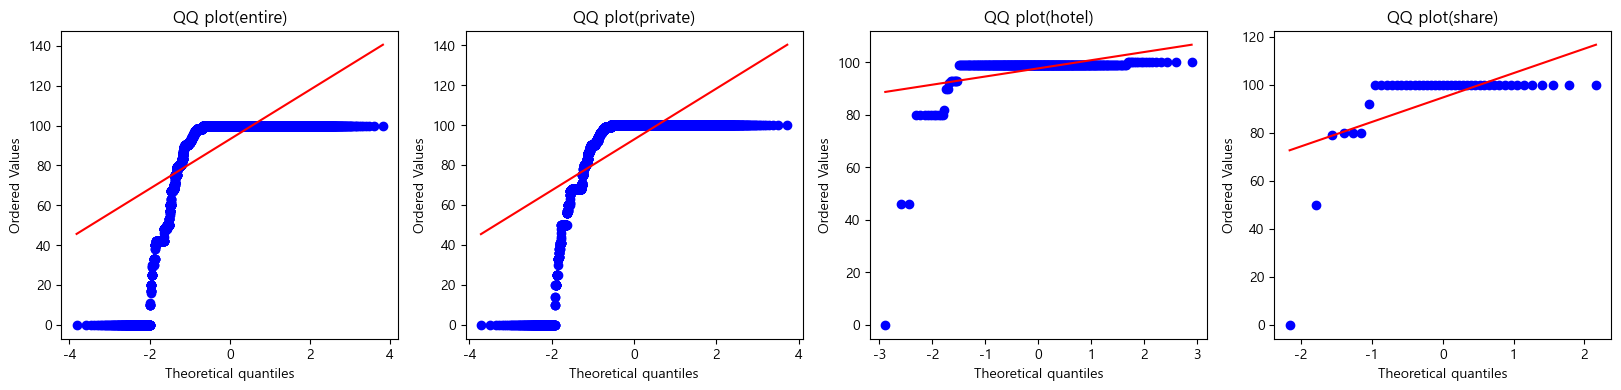

In [257]:
# q-q plot 시각화
fig, ax = plt.subplots(1,4, figsize=(20,4))
stats.probplot(rt1, plot=ax[0])
ax[0].set_title("QQ plot(entire)")
stats.probplot(rt2, plot=ax[1])
ax[1].set_title("QQ plot(private)")
stats.probplot(rt3, plot=ax[2])
ax[2].set_title("QQ plot(hotel)")
stats.probplot(rt4, plot=ax[3])
ax[3].set_title("QQ plot(share)")
plt.show()

- 각 그룹의 분포가 직선에서 많이 벗어나 있어 정규성을 만족한다고 보기 어렵다.

In [258]:
# 크루스칼 검정 통계량, p-value 계산
stat, p = stats.kruskal(rt1, rt2, rt3,rt4)
stat, p

(np.float64(392.93692498357836), np.float64(7.499519146636976e-85))

p-value < 0.05 보다 낮으므로 귀무가설 기각.

- 귀무가설 : 숙소 유형별로 호스트 응답률의 평균은 모두 같다.
- **대립가설 : 숙소 유형별로 호스트 응답률의 평균은 적어도 하나 이상 다르다.**

Q. 각 방 유형별로 호스트 응답률이 다 비슷비슷한가요?
- 숙소 유형에 따라 호스트 응답률 분포가 모두 같다고 보기 어렵다.
- 숙소 유형별로 호스트 응답률에 유의한 차이가 있다.

아뇨. 적어도 한 유형은 다른 유형과 달라요. 즉, 방 유형에 따라 호스트 응답률에 차이가 있다.(관련있음)
-> 어떤 방 유형이 차이가 있는지? -> 사후검정 필요

# 사후검정

In [259]:
# Dunn 사후검정 
data = temp[['room_type', 'host_response_rate']].dropna()

posthoc = sp.posthoc_dunn(data, 
                        val_col="host_response_rate",
                        group_col="room_type",
                        p_adjust="holm"
                        )

In [260]:
posthoc

,Entire home/apt,Hotel room,Private room,Shared room
Entire home/apt,1.000000e+00,2.310955e-85,1.285303e-04,1.893518e-01
Hotel room,2.310955e-85,1.000000e+00,1.886712e-74,9.767080e-15
Private room,1.285303e-04,1.886712e-74,1.000000e+00,1.659382e-01
Shared room,1.893518e-01,9.767080e-15,1.659382e-01,1.000000e+00


결과해석
- p-value < 0.05 → 두 그룹 차이 있음
- p-value >= 0.05 → 두 그룹 차이 있다고 보기 어려움

1. 차이가 있는 조합
    - Entire home/apt <-> Hotel room
    - Entire home/apt <-> Private room
    - Hotel room <-> Private room
    - Hotel room <-> Shared room

2. 차이가 없는 조합
    - Entire home/apt <-> Shared room
    - Private room <-> Shared room

Hotel room은 다른 방 유형과 유의한 차이를 보였고,
Shared room은 Entire home/apt, Private room과는 유의한 차이가 나타나지 않았다.

## 그렇다면.. 응답률은 가격에 영향을 미치는가?

In [261]:
rr_price = df[['host_response_rate', 'log_price']].copy()
rr_price = rr_price[(rr_price['host_response_rate'] != -1)].dropna()

<Axes: xlabel='host_response_rate', ylabel='log_price'>

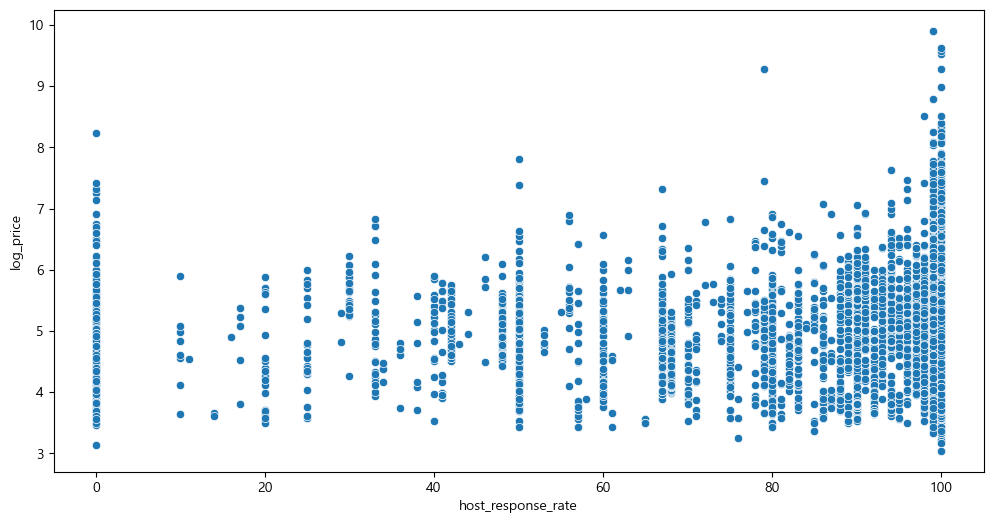

In [262]:
#산점도 확인
sns.scatterplot(data=rr_price, x='host_response_rate', y='log_price')


응답률이 낮더라도 가격은 천차만별인 것 같다. 별로 상관없는 것 같음

In [263]:
rr_price[['host_response_rate','log_price']].corr(method='pearson')

,host_response_rate,log_price
host_response_rate,1.000000,0.083587
log_price,0.083587,1.000000


In [264]:
rr_price[['host_response_rate','log_price']].corr(method='spearman')

,host_response_rate,log_price
host_response_rate,1.000000,0.112864
log_price,0.112864,1.000000


해석
- 피어슨 0.08, 스피어만 0.11로 매우 약한 상관관계
- 호스트 응답률이 높을수록 가격이 높아진다고 보기 어렵다.

### 종합결론
그럼 결국 방 유형별로 호스트 응답률은 통계적으로 유의한 차이가 있었지만, \
호스트 응답률이 가격 설정에 중요한 요인이라고 보기는 어렵다.

---
## 방 유형(Entire home/apt, Private room)에 따라 예약 요청 수락률에 차이가 있는가?


### 1. 가설설정 - 독립표본 t-test -> Mann-Whitney U검정
방 유형(Entire home/apt, Private room)에 따라 예약 요청 수락률에 차이가 있는가?
- 귀무가설 : Entire home/apt,Private room의 예약 요청 수락률 분포 차이가 없다.
- 대립가설 : Entire home/apt,Private room의 예약 요청 수락률 분포 차이가 있다.

Entire home/apt,Private room

### 0.데이터확인

In [265]:
df_2group = df[df['room_type'].isin(['Entire home/apt', 'Private room'])]
df_2group['room_type'].value_counts()

room_type
Entire home/apt    12635
Private room        9178
Name: count, dtype: int64

In [271]:
display(df['host_acceptance_rate'].isna().sum())
display(df['host_acceptance_rate'].value_counts(dropna=False).head(10))

np.int64(0)

host_acceptance_rate
100.0    4888
87.0     3559
97.0     1407
99.0     1006
0.0       997
83.0      473
77.0      473
88.0      462
50.0      451
96.0      422
Name: count, dtype: int64

두가지 방 유형만 비교 'Entire home/apt' , 'Private room'

In [275]:
rh1 = df.loc[df['room_type']=='Entire home/apt','host_acceptance_rate'].dropna()
rh2 = df.loc[df['room_type']=='Private room','host_acceptance_rate'].dropna()

In [282]:
rh1.head()

3      97.0
7     100.0
12     96.0
13     87.0
15     87.0
Name: host_acceptance_rate, dtype: float64

In [276]:
rh1.shape, rh2.shape
rh1.describe(), rh2.describe()

(count    12635.000000
 mean        78.748556
 std         26.430551
 min          0.000000
 25%         69.000000
 50%         87.000000
 75%         99.000000
 max        100.000000
 Name: host_acceptance_rate, dtype: float64,
 count    9178.000000
 mean       80.131292
 std        25.484087
 min         0.000000
 25%        77.000000
 50%        87.000000
 75%        99.000000
 max       100.000000
 Name: host_acceptance_rate, dtype: float64)

### 01-1. 박스플롯

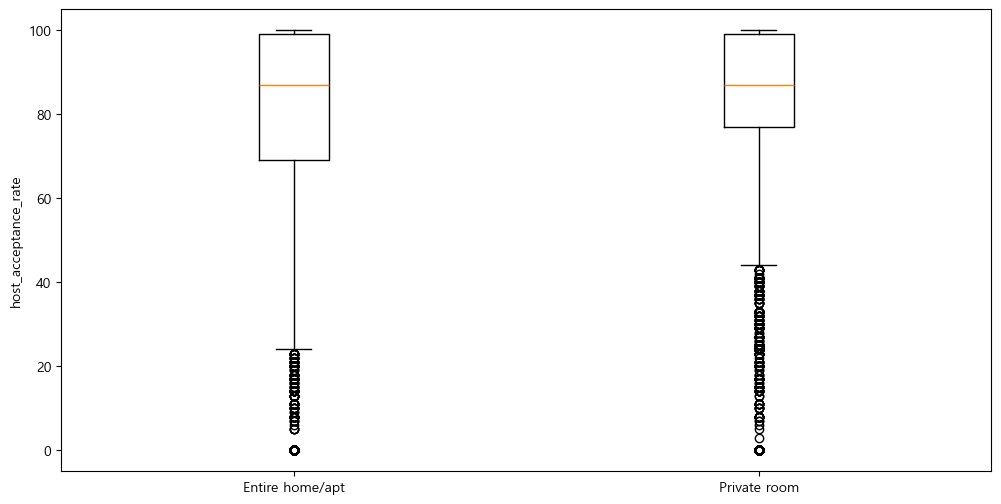

In [279]:
plt.boxplot([rh1, rh2], labels=['Entire home/apt', 'Private room'])
plt.ylabel('host_acceptance_rate')
plt.show()

- 중앙값(주황색)이 거의 비슷해 보임
- Private room에 이상치가 좀 더 많아보인다.
- 전체적인 중심 위치 차이는 크지 않아 보인다.

=> 두 방 유형의 예약 요청 수락률 분포가 아주 크게 다르지는 않아 보임.

In [284]:
# 두 집단 표본의 크기 맞추기 

rh1_group = rh1.sample(5000, random_state=42)
rh2_group = rh2.sample(5000, random_state=42)

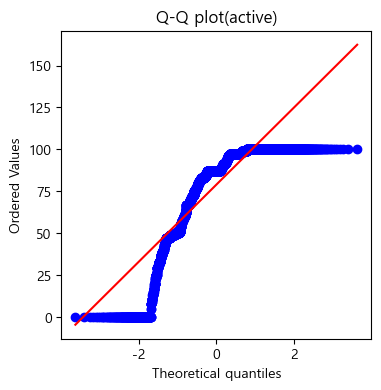

In [285]:
# 정규성 검정 1. Q-Q Plot

plt.figure(figsize=(4,4))
stats.probplot(rh1_group, plot=plt)
plt.title("Q-Q plot(active)")
plt.show()

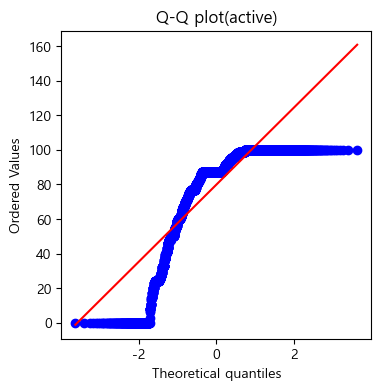

In [286]:
# 정규성 검정 1. Q-Q Plot

plt.figure(figsize=(4,4))
stats.probplot(rh2_group, plot=plt)
plt.title("Q-Q plot(active)")
plt.show()

In [287]:
# 정규성 검정 2. Kolmogorov - Sminov

# 표본 평균
sample_mean = np.mean(rh1_group)
# 표본 표준편차
s = np.std(rh1_group, ddof=1)

stat, p = stats.kstest(rh1_group, 'norm', args=(sample_mean, s))

stat, p

(np.float64(0.217032594496277), np.float64(3.043176033504192e-207))

In [288]:
# 정규성 검정 2. Kolmogorov - Sminov

# 표본 평균
sample_mean = np.mean(rh2_group)
# 표본 표준편차
s = np.std(rh2_group, ddof=1)

stat, p = stats.kstest(rh2_group, 'norm', args=(sample_mean, s))

stat, p

(np.float64(0.25177709624469996), np.float64(8.263711703044916e-280))

- 정규성 확인했을 때 정규성을 만족하지 않는다.

2. 검정방법 선택 : 맨-휘트니 U-검정
3. 유의수준 : 0.05로 결정

In [290]:
u_stat, u_p = stats.mannwhitneyu(rh1_group, rh2_group, alternative="two-sided")
u_stat, u_p

(np.float64(12245872.0), np.float64(0.07592475124704974))

### 결과해석
p-value(0.075) > 유의수준(0.05) : 귀무가설을 기각하지 못함

- 귀무가설 : Entire home/apt,Private room의 예약 요청 수락률 분포 차이가 없다.
- 대립가설 : Entire home/apt,Private room의 예약 요청 수락률 분포 차이가 있다.

Q. 방 유형(Entire home/apt, Private room)에 따라 예약 요청 수락률에 차이가 있는가?
- 검정 결과 p-value > 0.05 이므로 귀무가설을 기각하지 못했다.
- 따라서 방 유형에 따라 예약 요청 수략률이 통계적으로 유의하게 다르다고 보기 어렵다.(차이가 있다고 할 만큼 근거를 찾지 못함.)

